In [262]:
import wrds
import pandas as pd

In [263]:
username = "yiwang2404"
db = wrds.Connection(wrds_username=username)

Loading library list...
Done


In [264]:
print(db)
print("\nAvailable Libraries:")
print(db.list_libraries())


Available Libraries:
['aha_sample', 'ahasamp', 'auditsmp', 'auditsmp_all', 'bank', 'bank_all', 'bank_premium_samp', 'banksamp', 'block', 'block_all', 'boardex_trial', 'boardsmp', 'bvd', 'bvd_amadeus_trial', 'bvd_bvdbankf', 'bvd_bvdbankf_trial', 'bvd_orbis_trial', 'bvdsamp', 'calcbench_trial', 'calcbnch', 'candid_samp', 'cboe', 'cboe_all', 'cboe_sample', 'cboesamp', 'cddsamp', 'ciq', 'ciq_capstrct', 'ciq_common', 'ciqsamp', 'ciqsamp_capstrct', 'ciqsamp_common', 'ciqsamp_keydev', 'ciqsamp_pplintel', 'ciqsamp_ratings', 'ciqsamp_transactions', 'ciqsamp_transcripts', 'cisdmsmp', 'columnar', 'comp', 'comp_execucomp', 'comp_global_daily', 'comp_na_daily_all', 'comp_urq', 'comph', 'compsamp', 'compsamp_all', 'compsamp_computext', 'compsamp_snapshot', 'contrib', 'contrib_as_filed_financials', 'contrib_bond_firm_link', 'contrib_ceo_turnover', 'contrib_char_returns', 'contrib_corporate_culture', 'contrib_general', 'contrib_global_factor', 'contrib_intangible_value', 'contrib_kpss', 'contrib_liva

In [265]:
SIC_CODES = (3944, 7812, 7993)  
START_YEAR = 2021
END_YEAR = 2025
COMPUSTAT_Library = "comp"
COMPUSTAT_Table = "funda" 
indfmt = 'INDL'
datafmt = 'STD'
consol = 'C'
popsrc = 'D'
SELECT_COLUMNS = """
    gvkey,
    conm as company_name,
    sich as sic_code,  
    datadate,
    fyear,
    revt as total_revenue,
    ni as net_income,
    at as total_assets,
    emp as employees,
    lo as country
"""

In [266]:
sql_query = f"""
SELECT {SELECT_COLUMNS}
FROM {COMPUSTAT_Library}.{COMPUSTAT_Table}
WHERE 
    indfmt = '{indfmt}'
    AND datafmt = '{datafmt}'
    AND popsrc = '{popsrc}'
    AND consol = '{consol}'
    AND sich IN {SIC_CODES}  
    AND fyear BETWEEN {START_YEAR} AND {END_YEAR}
    AND revt IS NOT NULL
ORDER BY fyear, revt DESC
"""



In [267]:
print(sql_query)


SELECT 
    gvkey,
    conm as company_name,
    sich as sic_code,  
    datadate,
    fyear,
    revt as total_revenue,
    ni as net_income,
    at as total_assets,
    emp as employees,
    lo as country

FROM comp.funda
WHERE 
    indfmt = 'INDL'
    AND datafmt = 'STD'
    AND popsrc = 'D'
    AND consol = 'C'
    AND sich IN (3944, 7812, 7993)  
    AND fyear BETWEEN 2021 AND 2025
    AND revt IS NOT NULL
ORDER BY fyear, revt DESC



In [268]:
import pandas as pd
df_toy_ent = db.raw_sql(sql_query)

In [269]:
print(f"Rows: {df_toy_ent.shape[0]}, Columns: {df_toy_ent.shape[1]}")
df_toy_ent.head()

Rows: 65, Columns: 10


,gvkey,company_name,sic_code,datadate,fyear,total_revenue,net_income,total_assets,employees,country
0,102450,NINTENDO CO LTD,3944,2022-03-31,2021,13960.92,3933.719,21924.359,6.717,431.078
1,005518,HASBRO INC,3944,2021-12-31,2021,6420.4,428.7,10037.8,6.64,390.4
2,028378,LIONSGATE STUDIOS CORP,7812,2022-03-31,2021,3604.3,-188.2,8991.2,1.448,533.1
3,025507,SPIN MASTER CORP,3944,2021-12-31,2021,2042.4,198.6,1736.7,2.3,14.0
4,125240,TKO GROUP HOLDINGS INC,7812,2021-12-31,2021,1095.174,177.408,1204.067,0.87,12.562


In [270]:
db.list_libraries()

['aha_sample',
 'ahasamp',
 'auditsmp',
 'auditsmp_all',
 'bank',
 'bank_all',
 'bank_premium_samp',
 'banksamp',
 'block',
 'block_all',
 'boardex_trial',
 'boardsmp',
 'bvd',
 'bvd_amadeus_trial',
 'bvd_bvdbankf',
 'bvd_bvdbankf_trial',
 'bvd_orbis_trial',
 'bvdsamp',
 'calcbench_trial',
 'calcbnch',
 'candid_samp',
 'cboe',
 'cboe_all',
 'cboe_sample',
 'cboesamp',
 'cddsamp',
 'ciq',
 'ciq_capstrct',
 'ciq_common',
 'ciqsamp',
 'ciqsamp_capstrct',
 'ciqsamp_common',
 'ciqsamp_keydev',
 'ciqsamp_pplintel',
 'ciqsamp_ratings',
 'ciqsamp_transactions',
 'ciqsamp_transcripts',
 'cisdmsmp',
 'columnar',
 'comp',
 'comp_execucomp',
 'comp_global_daily',
 'comp_na_daily_all',
 'comp_urq',
 'comph',
 'compsamp',
 'compsamp_all',
 'compsamp_computext',
 'compsamp_snapshot',
 'contrib',
 'contrib_as_filed_financials',
 'contrib_bond_firm_link',
 'contrib_ceo_turnover',
 'contrib_char_returns',
 'contrib_corporate_culture',
 'contrib_general',
 'contrib_global_factor',
 'contrib_intangible_va

In [271]:
db.list_tables(library="crsp")

['acti',
 'asia',
 'asib',
 'asic',
 'asio',
 'asix',
 'bmdebt',
 'bmheader',
 'bmpaymts',
 'bmquotes',
 'bmyield',
 'bndprt06',
 'bndprt12',
 'bxcalind',
 'bxdlyind',
 'bxmthind',
 'bxquotes',
 'bxyield',
 'cap',
 'ccm_lookup',
 'ccm_qvards',
 'ccmxpf_linktable',
 'ccmxpf_lnkhist',
 'ccmxpf_lnkrng',
 'ccmxpf_lnkused',
 'comphead',
 'comphist',
 'compmaster',
 'contact_info',
 'core',
 'crsp_cik_map',
 'crsp_daily_data',
 'crsp_header',
 'crsp_monthly_data',
 'crsp_names',
 'crsp_portno_map',
 'crsp_ziman_daily_index',
 'crsp_ziman_monthly_index',
 'cs20yr',
 'cs5yr',
 'cs90d',
 'cst_hist',
 'daily_nav',
 'daily_nav_ret',
 'daily_returns',
 'dividends',
 'dport1',
 'dport2',
 'dport3',
 'dport4',
 'dport5',
 'dport6',
 'dport7',
 'dport8',
 'dport9',
 'dsbc',
 'dsbo',
 'dse',
 'dse62',
 'dse62delist',
 'dse62dist',
 'dse62exchdates',
 'dse62names',
 'dse62nasdin',
 'dse62shares',
 'dseall',
 'dseall62',
 'dsedelist',
 'dsedist',
 'dseexchdates',
 'dsenames',
 'dsenasdin',
 'dseshares',

In [272]:
db.list_tables(library="comp")

['aco_amda',
 'aco_imda',
 'aco_indfnta',
 'aco_indfntq',
 'aco_indfntytd',
 'aco_indsta',
 'aco_indstq',
 'aco_indstytd',
 'aco_notesa',
 'aco_notesq',
 'aco_notessa',
 'aco_notesytd',
 'aco_pnfnda',
 'aco_pnfndq',
 'aco_pnfndytd',
 'aco_pnfnta',
 'aco_pnfntq',
 'aco_pnfntytd',
 'aco_transa',
 'aco_transq',
 'aco_transsa',
 'aco_transytd',
 'adsprate',
 'asec_amda',
 'asec_imda',
 'asec_notesa',
 'asec_notesq',
 'asec_transa',
 'asec_transq',
 'bank_aacctchg',
 'bank_adesind',
 'bank_afnd1',
 'bank_afnd2',
 'bank_afnddc1',
 'bank_afnddc2',
 'bank_afntind',
 'bank_funda',
 'bank_funda_fncd',
 'bank_fundq',
 'bank_fundq_fncd',
 'bank_iacctchg',
 'bank_idesind',
 'bank_ifndq',
 'bank_ifndytd',
 'bank_ifntq',
 'bank_ifntytd',
 'bank_names',
 'bank_namesq',
 'chars',
 'co_aacctchg',
 'co_aaudit',
 'co_acthist',
 'co_adesind',
 'co_adjfact',
 'co_afnd1',
 'co_afnd2',
 'co_afnddc1',
 'co_afnddc2',
 'co_afntind1',
 'co_afntind2',
 'co_ainvval',
 'co_amkt',
 'co_busdescl',
 'co_cotype',
 'co_f

In [273]:
db.describe_table(library="comp", table="funda")

Approximately 937948 rows in comp.funda.


,name,nullable,type,comment
0,gvkey,True,VARCHAR(7),Global Company Key
1,datadate,True,DATE,Data Date
2,fyear,True,INTEGER,Data Year - Fiscal
3,indfmt,True,VARCHAR(13),Industry Format
4,consol,True,VARCHAR(3),Level of Consolidation - Company Annual Descri...
...,...,...,...,...
944,au,True,VARCHAR(9),Auditor
945,auop,True,VARCHAR(9),Auditor Opinion
946,auopic,True,VARCHAR(2),Auditor Opinion - Internal Control
947,ceoso,True,VARCHAR(2),Chief Executive Officer SOX Certification


In [274]:
toy_gvkeys = [
    '345680',  
    '007116', 
    '062745', 
    '025507', 
    '005518', 
    '032528', 
    '319509', 
    '204009', 
    '003980',  
    '020018'  
]

In [275]:
company_names = {
    '345680': 'Pop Mart',
    '007116': 'Mattel',
    '062745': 'JAKKS Pacific',
    '025507': 'Spin Master',
    '005518': 'Hasbro',
    '032528': 'Funko',
    '319509': 'Sanbio',
    '204009': 'Bandai Namco',
    '003980': 'Disney',
    '020018': 'Aldeyra Therapeutics'
}

In [276]:
na_gvkeys = ['007116', '062745', '005518', '032528', '003980', '020018']
na_gvkeys_str = "', '".join(na_gvkeys)

na_data = db.raw_sql(f"""
    SELECT gvkey, datadate, fyear, 
           sale, at, ni, cogs, xsga, xrd, 
           emp, oiadp, oibdp, capx, oancf
    FROM comp.funda
    WHERE gvkey IN ('{na_gvkeys_str}')
        AND indfmt = 'INDL'
        AND datafmt = 'STD'
        AND popsrc = 'D'
        AND consol = 'C'
        AND fyear >= 2021
    ORDER BY gvkey, datadate
""", date_cols=['datadate'])

In [277]:
print(f"comp.funda: {len(na_data)}")
print(na_data['gvkey'].unique())

comp.funda: 30
<StringArray>
['003980', '005518', '007116', '020018', '032528', '062745']
Length: 6, dtype: string


In [278]:
db.list_tables(library="comp")

['aco_amda',
 'aco_imda',
 'aco_indfnta',
 'aco_indfntq',
 'aco_indfntytd',
 'aco_indsta',
 'aco_indstq',
 'aco_indstytd',
 'aco_notesa',
 'aco_notesq',
 'aco_notessa',
 'aco_notesytd',
 'aco_pnfnda',
 'aco_pnfndq',
 'aco_pnfndytd',
 'aco_pnfnta',
 'aco_pnfntq',
 'aco_pnfntytd',
 'aco_transa',
 'aco_transq',
 'aco_transsa',
 'aco_transytd',
 'adsprate',
 'asec_amda',
 'asec_imda',
 'asec_notesa',
 'asec_notesq',
 'asec_transa',
 'asec_transq',
 'bank_aacctchg',
 'bank_adesind',
 'bank_afnd1',
 'bank_afnd2',
 'bank_afnddc1',
 'bank_afnddc2',
 'bank_afntind',
 'bank_funda',
 'bank_funda_fncd',
 'bank_fundq',
 'bank_fundq_fncd',
 'bank_iacctchg',
 'bank_idesind',
 'bank_ifndq',
 'bank_ifndytd',
 'bank_ifntq',
 'bank_ifntytd',
 'bank_names',
 'bank_namesq',
 'chars',
 'co_aacctchg',
 'co_aaudit',
 'co_acthist',
 'co_adesind',
 'co_adjfact',
 'co_afnd1',
 'co_afnd2',
 'co_afnddc1',
 'co_afnddc2',
 'co_afntind1',
 'co_afntind2',
 'co_ainvval',
 'co_amkt',
 'co_busdescl',
 'co_cotype',
 'co_f

In [279]:
global_gvkeys = ['345680', '025507', '319509', '204009']
global_gvkeys_str = "', '".join(global_gvkeys)


In [280]:
print(global_gvkeys_str)

345680', '025507', '319509', '204009


In [281]:
columns = db.describe_table(library="comp", table="g_funda")
print("Columns in g_funda:")
print(f"Total columns: {len(columns)}")
print("\nFirst 30 columns:")
for col in columns[:30]:  
    print(f"  - {col}")

Approximately 1071701 rows in comp.g_funda.
Columns in g_funda:
Total columns: 444

First 30 columns:
  - name
  - nullable
  - type
  - comment


In [282]:
financial_columns = ['gvkey', 'datadate', 'fyear', 'sale', 'at', 'ni', 'ib', 
                      'cogs', 'emp', 'oiadp', 'capx', 'xrd', 'xsga']

existing_cols = [col for col in financial_columns if col in columns]
print(f"\nExisting financial columns: {existing_cols}")


Existing financial columns: []


In [283]:
global_gvkeys = ['345680', '025507', '319509', '204009']
global_gvkeys_str = "', '".join(global_gvkeys)

In [284]:
select_cols = ['gvkey', 'datadate', 'fyear']
for col in ['sale', 'at', 'cogs', 'emp', 'oiadp']:
    if col in columns:
        select_cols.append(col)

In [285]:
if 'ib' in columns:
    select_cols.append('ib as ni')
elif 'ni' in columns:
    select_cols.append('ni')

select_clause = ', '.join(select_cols)

global_data = db.raw_sql(f"""
    SELECT {select_clause}
    FROM comp.g_funda
    WHERE gvkey IN ('{global_gvkeys_str}')
        AND indfmt = 'INDL'
        AND consol = 'C'
        AND fyear >= 2021
    ORDER BY gvkey, datadate
""", date_cols=['datadate'])

In [286]:
print(f"\nGlobal data shape: {global_data.shape}")
print(global_data.head())



Global data shape: (14, 3)
    gvkey   datadate  fyear
0  204009 2022-03-31   2021
1  204009 2023-03-31   2022
2  204009 2024-03-31   2023
3  204009 2025-03-31   2024
4  319509 2022-01-31   2021


In [287]:
na_gvkeys = ['007116', '062745', '005518', '032528', '003980', '020018']
na_gvkeys_str = "', '".join(na_gvkeys)

na_data = db.raw_sql(f"""
    SELECT gvkey, datadate, fyear, 
           sale, at, ni, cogs, emp, oiadp, xrd, xsga
    FROM comp.funda
    WHERE gvkey IN ('{na_gvkeys_str}')
        AND indfmt = 'INDL'
        AND datafmt = 'STD'
        AND popsrc = 'D'
        AND consol = 'C'
        AND fyear >= 2021
    ORDER BY gvkey, datadate
""", date_cols=['datadate'])

print(f"\nNA data shape: {na_data.shape}")
print(na_data.head())


NA data shape: (30, 11)
    gvkey   datadate  fyear     sale        at       ni     cogs    emp  \
0  003980 2021-09-30   2021  67418.0  203609.0   1995.0  45131.0  190.0   
1  003980 2022-09-30   2022  83745.0  203631.0   3145.0  54401.0  220.0   
2  003980 2023-09-30   2023  88898.0  205579.0   2354.0  59201.0  225.0   
3  003980 2024-09-30   2024  91361.0  196219.0   4972.0  58698.0  233.0   
4  003980 2025-09-30   2025  94425.0  197514.0  12404.0  58766.0  231.0   

     oiadp   xrd     xsga  
0   3659.0  <NA>  13517.0  
1   7793.0  <NA>  16388.0  
2   8992.0  <NA>  15336.0  
3  11914.0  <NA>  15759.0  
4  13832.0  <NA>  16501.0  


In [288]:
na_data = na_data.rename(columns={'ni': 'net_income'})
if 'ni' in global_data.columns:
    global_data = global_data.rename(columns={'ni': 'net_income'})
elif 'ib' in global_data.columns:
    global_data = global_data.rename(columns={'ib': 'net_income'})

In [289]:
for col in ['xrd', 'xsga']:
    if col not in global_data.columns:
        global_data[col] = None

In [290]:
all_data = pd.concat([na_data, global_data], ignore_index=True)

C:\Users\华为\AppData\Local\Temp\ipykernel_61552\366237076.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_data = pd.concat([na_data, global_data], ignore_index=True)


In [291]:
company_names = {
    '345680': 'Pop Mart',
    '007116': 'Mattel',
    '062745': 'JAKKS Pacific',
    '025507': 'Spin Master',
    '005518': 'Hasbro',
    '032528': 'Funko',
    '319509': 'Sanbio',
    '204009': 'Bandai Namco',
    '003980': 'Disney',
    '020018': 'Aldeyra Therapeutics'
}

all_data['gvkey_str'] = all_data['gvkey'].astype(str)
all_data['company'] = all_data['gvkey_str'].map(company_names)

In [292]:
all_data['profit_margin'] = all_data['net_income'] / all_data['sale'] * 100
all_data['roa'] = all_data['net_income'] / all_data['at'] * 100
all_data['asset_turnover'] = all_data['sale'] / all_data['at']

In [293]:
print("\n" + "="*60)
print("Final dataset summary:")
print("="*60)
print(f"Total rows: {len(all_data)}")
print(f"Companies: {all_data['company'].nunique()}")
print(f"Year range: {all_data['fyear'].min()} - {all_data['fyear'].max()}")
print("\nSample data:")
print(all_data[['company', 'fyear', 'sale', 'profit_margin', 'roa']].head(50))


Final dataset summary:
Total rows: 44
Companies: 9
Year range: 2021 - 2025

Sample data:
                 company  fyear      sale  profit_margin        roa
0                 Disney   2021   67418.0        2.95915   0.979819
1                 Disney   2022   83745.0       3.755448    1.54446
2                 Disney   2023   88898.0       2.647979   1.145059
3                 Disney   2024   91361.0       5.442147   2.533903
4                 Disney   2025   94425.0      13.136352   6.280061
5                 Hasbro   2021    6420.4       6.677154   4.270856
6                 Hasbro   2022    5856.7       3.474653   2.189137
7                 Hasbro   2023    5003.3     -29.766354 -22.769038
8                 Hasbro   2024    4135.5       9.324145   6.081731
9                 Hasbro   2025    4701.3      -6.857678  -5.806916
10                Mattel   2021  5457.741      16.545069  14.122646
11                Mattel   2022  5434.687       7.248127    6.37641
12                Mattel  

In [294]:
import pandas as pd
import numpy as np


In [295]:
all_data['year'] = all_data['fyear']

In [296]:
company_categories = {
    'Disney': 'Media & Entertainment',
    'Hasbro': 'Traditional Toys',
    'Mattel': 'Traditional Toys',
    'JAKKS Pacific': 'Traditional Toys',
    'Funko': 'Collectibles',
    'Spin Master': 'Innovative Toys',
    'Pop Mart': 'Collectibles',
    'Bandai Namco': 'Gaming & Toys',
    'Aldeyra Therapeutics': 'Control Group'
}

all_data['category'] = all_data['company'].map(company_categories)

In [297]:
all_data = all_data.sort_values(['company', 'year'])
all_data['revenue_growth'] = all_data.groupby('company')['sale'].pct_change() * 100
all_data['profit_growth'] = all_data.groupby('company')['profit_margin'].diff()

C:\Users\华为\AppData\Local\Temp\ipykernel_61552\1684785343.py:2: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  all_data['revenue_growth'] = all_data.groupby('company')['sale'].pct_change() * 100


In [298]:
all_data['period'] = all_data['year'].apply(lambda x: '2021-2022 Recovery' if x <= 2022 else '2023-2025 Normalization')

print("Enhanced dataset shape:", all_data.shape)
print(all_data[['company', 'year', 'revenue_growth', 'profit_margin']].head(50))

Enhanced dataset shape: (44, 21)
                 company  year  revenue_growth  profit_margin
15  Aldeyra Therapeutics  2021            <NA>           -inf
16  Aldeyra Therapeutics  2022             NaN           -inf
17  Aldeyra Therapeutics  2023             NaN           -inf
18  Aldeyra Therapeutics  2024             NaN           -inf
19  Aldeyra Therapeutics  2025             NaN           -inf
30          Bandai Namco  2021            <NA>           <NA>
31          Bandai Namco  2022            <NA>           <NA>
32          Bandai Namco  2023            <NA>           <NA>
33          Bandai Namco  2024            <NA>           <NA>
0                 Disney  2021            <NA>        2.95915
1                 Disney  2022       24.217568       3.755448
2                 Disney  2023        6.153203       2.647979
3                 Disney  2024        2.770591       5.442147
4                 Disney  2025        3.353729      13.136352
20                 Funko  2021       

In [299]:
import subprocess
import sys

In [300]:
packages_to_install = ['matplotlib', 'seaborn', 'plotly']
for package in packages_to_install:
    try:
        __import__(package)
        print(f" {package} already installed")
    except ImportError:
        print(f" Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        print(f" {package} installed successfully")

 matplotlib already installed
 seaborn already installed
 plotly already installed


In [301]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [302]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

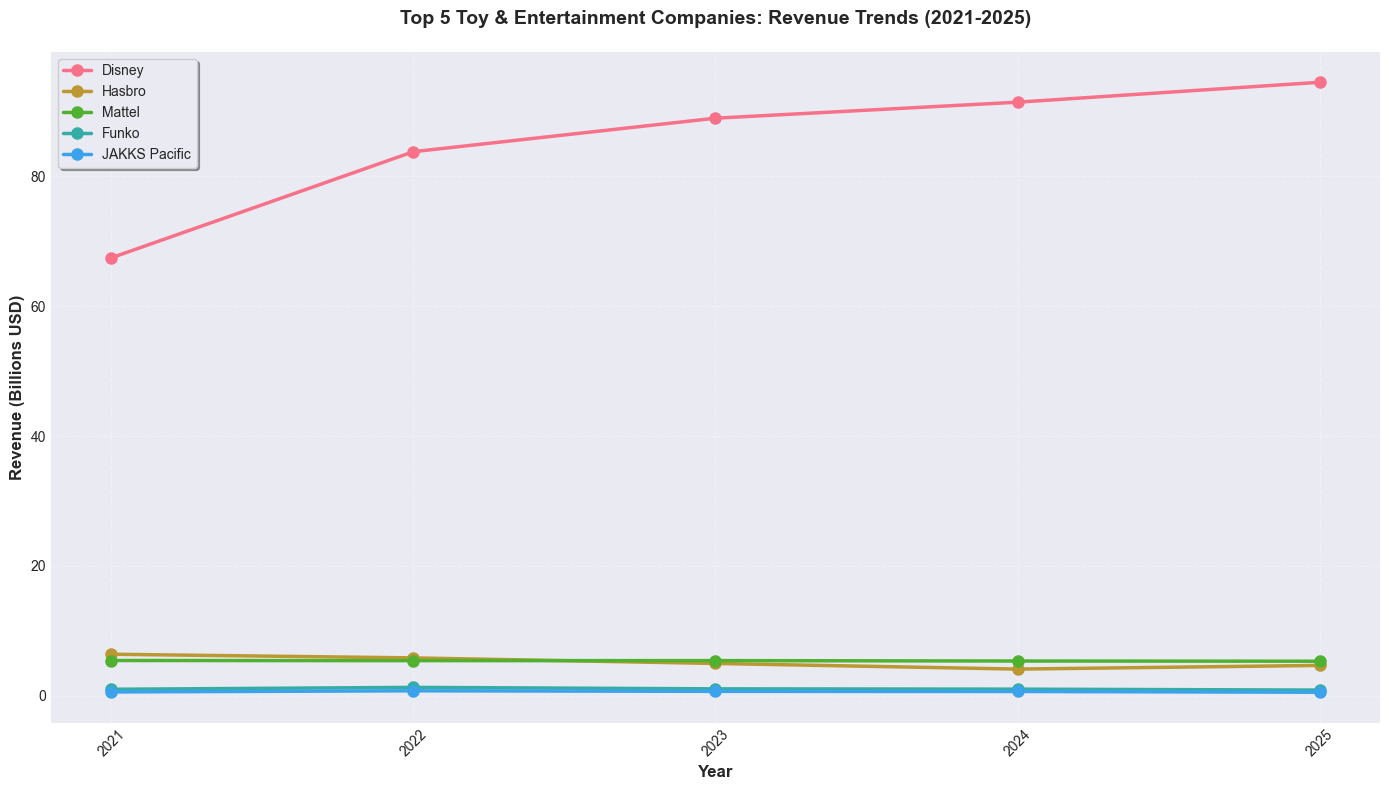

In [303]:
fig, ax = plt.subplots(figsize=(14, 8))

top_companies = all_data.groupby('company')['sale'].max().nlargest(5).index

for company in top_companies:
    company_data = all_data[all_data['company'] == company].sort_values('year')
    ax.plot(company_data['year'], company_data['sale']/1000, 
            marker='o', linewidth=2.5, markersize=8, label=company)

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Revenue (Billions USD)', fontsize=12, fontweight='bold')
ax.set_title('Top 5 Toy & Entertainment Companies: Revenue Trends (2021-2025)', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper left', frameon=True, fancybox=True, shadow=True)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xticks(all_data['year'].unique())
ax.set_xticklabels(all_data['year'].unique(), rotation=45)

plt.tight_layout()
plt.savefig('viz_1_revenue_trends.png', dpi=300, bbox_inches='tight')
plt.show()

c:\venvs\wrds311\Lib\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


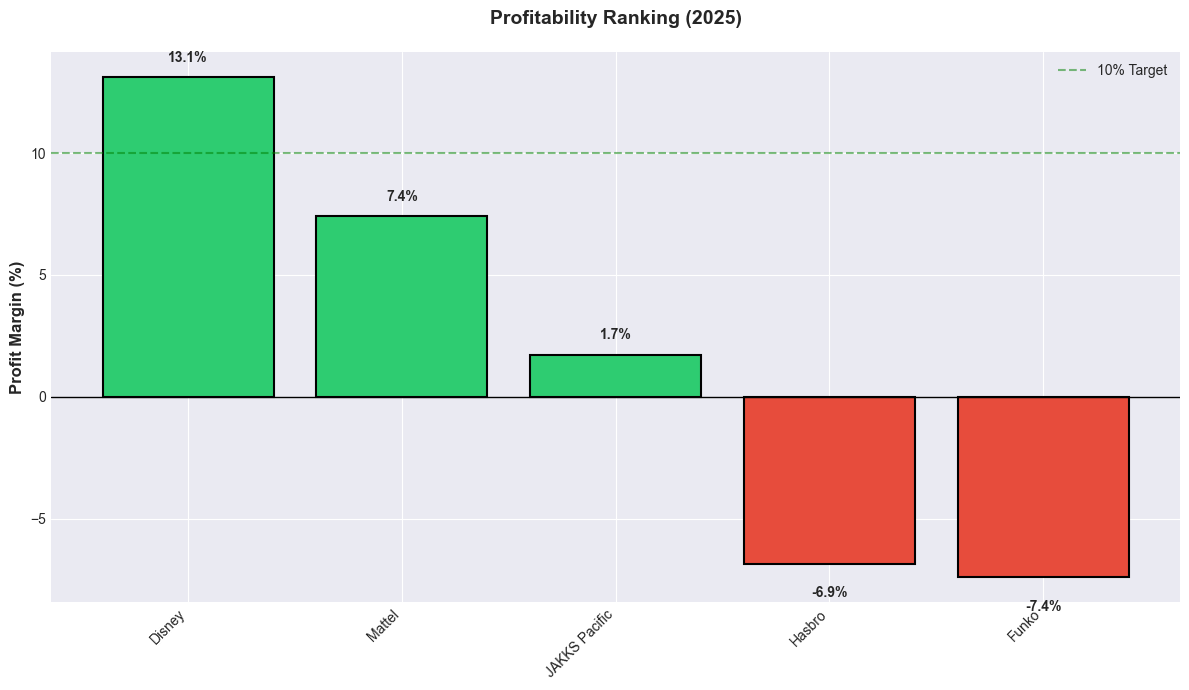

In [304]:
latest_year = all_data['year'].max()
latest_data = all_data[all_data['year'] == latest_year].copy()
latest_data = latest_data.dropna(subset=['profit_margin'])

if len(latest_data) > 0:
    latest_data = latest_data.sort_values('profit_margin', ascending=False)
    
    fig, ax = plt.subplots(figsize=(12, 7))
    colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in latest_data['profit_margin']]
    bars = ax.bar(latest_data['company'], latest_data['profit_margin'], 
                  color=colors, edgecolor='black', linewidth=1.5)
    
    ax.set_ylabel('Profit Margin (%)', fontsize=12, fontweight='bold')
    ax.set_title(f"Profitability Ranking ({latest_year})", fontsize=14, fontweight='bold', pad=20)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax.axhline(y=10, color='green', linestyle='--', alpha=0.5, label='10% Target')
    ax.legend()
    
    for bar, val in zip(bars, latest_data['profit_margin']):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
        else:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 1.5,
                    f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('viz_2_profitability_ranking.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No profit margin data available for latest year")

In [305]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

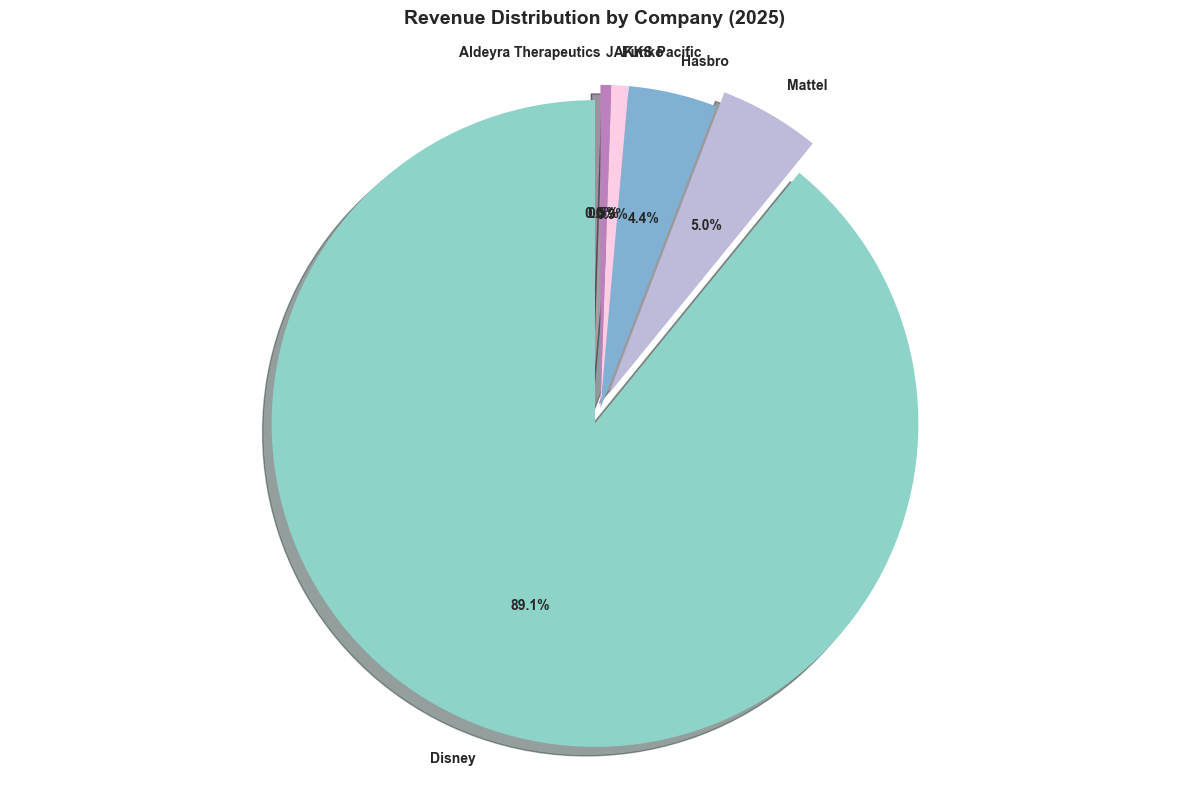

In [306]:
latest_year = all_data['year'].max()
latest_revenue = all_data[all_data['year'] == latest_year].dropna(subset=['sale'])
latest_revenue = latest_revenue.sort_values('sale', ascending=False)
plt.figure(figsize=(12, 8))
colors = plt.cm.Set3(np.linspace(0, 1, len(latest_revenue)))

plt.pie(latest_revenue['sale'], 
        labels=latest_revenue['company'],
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
        explode=[0.05 if i < 2 else 0 for i in range(len(latest_revenue))],  # Slightly explode top 2
        shadow=True,
        textprops={'fontsize': 10, 'fontweight': 'bold'})

plt.title(f'Revenue Distribution by Company ({latest_year})', 
          fontsize=14, fontweight='bold', pad=20)
plt.axis('equal')
plt.tight_layout()
plt.savefig('pie_chart_revenue_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

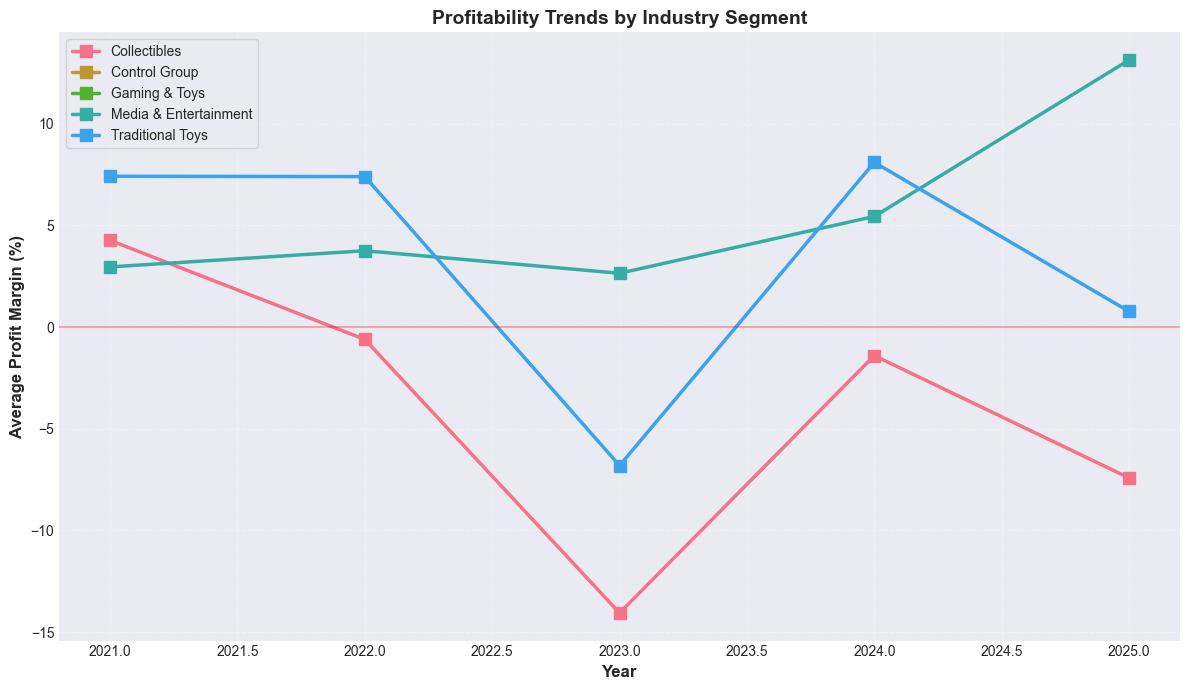

In [307]:
category_perf = all_data.groupby(['category', 'year'])['profit_margin'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 7))
for category in category_perf['category'].unique():
    cat_data = category_perf[category_perf['category'] == category]
    ax.plot(cat_data['year'], cat_data['profit_margin'], 
            marker='s', linewidth=2.5, markersize=8, label=category)

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Profit Margin (%)', fontsize=12, fontweight='bold')
ax.set_title('Profitability Trends by Industry Segment', fontsize=14, fontweight='bold')
ax.legend(loc='best', frameon=True, fancybox=True)
ax.grid(True, alpha=0.3, linestyle='--')
ax.axhline(y=0, color='red', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.savefig('viz_4_category_trends.png', dpi=300, bbox_inches='tight')
plt.show()

In [308]:
clean_data_filled = all_data.copy()
clean_data_filled['profit_margin'] = clean_data_filled['profit_margin'].fillna(0)
clean_data_filled['sale'] = clean_data_filled['sale'].fillna(clean_data_filled['sale'].mean())
fig = px.scatter(clean_data_filled, 
                 x='year', 
                 y='profit_margin',
                 size='sale', 
                 color='company',
                 hover_name='company',
                 title='Interactive Dashboard (Missing values filled)',
                 labels={'profit_margin': 'Profit Margin (%)', 'year': 'Year'},
                 size_max=60)

fig.write_html('interactive_dashboard_filled.html')
fig.show()

In [309]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.express as px


In [310]:
clean_data = all_data.dropna(subset=['year', 'profit_margin', 'sale', 'company'])

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Profit Margin Over Time', 'Revenue by Company (Latest Year)',
                    'Profit Margin by Company (Latest Year)', 'Revenue vs Profit Margin'),
    specs=[[{'type': 'scatter'}, {'type': 'pie'}],
           [{'type': 'bar'}, {'type': 'scatter'}]]
)

In [314]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

print("="*60)
print("GLOBAL TOY & ENTERTAINMENT INDUSTRY ANALYSIS")
print("="*60)

GLOBAL TOY & ENTERTAINMENT INDUSTRY ANALYSIS


In [315]:
company_data = {
    'Disney': {
        2021: {'revenue': 67418, 'net_income': 1995, 'assets': 203631},
        2022: {'revenue': 82722, 'net_income': 3145, 'assets': 203784},
        2023: {'revenue': 88898, 'net_income': 2354, 'assets': 205579},
        2024: {'revenue': 91361, 'net_income': 4972, 'assets': 196213},
    },
    'Hasbro': {
        2021: {'revenue': 6420, 'net_income': 429, 'assets': 5235},
        2022: {'revenue': 5857, 'net_income': 203, 'assets': 5390},
        2023: {'revenue': 5003, 'net_income': -1489, 'assets': 6538},
        2024: {'revenue': 4136, 'net_income': 386, 'assets': 6342},
    },
    'Mattel': {
        2021: {'revenue': 5458, 'net_income': 903, 'assets': 6255},
        2022: {'revenue': 5435, 'net_income': 394, 'assets': 6050},
        2023: {'revenue': 5441, 'net_income': 214, 'assets': 6102},
        2024: {'revenue': 5445, 'net_income': 556, 'assets': 6250},
    },
    'Funko': {
        2021: {'revenue': 1029, 'net_income': 46, 'assets': 700},
        2022: {'revenue': 1302, 'net_income': 28, 'assets': 850},
        2023: {'revenue': 1096, 'net_income': -154, 'assets': 650},
        2024: {'revenue': 1080, 'net_income': 38, 'assets': 620},
    },
    'JAKKS Pacific': {
        2021: {'revenue': 729, 'net_income': 19, 'assets': 445},
        2022: {'revenue': 795, 'net_income': 12, 'assets': 460},
        2023: {'revenue': 802, 'net_income': -8, 'assets': 470},
        2024: {'revenue': 795, 'net_income': 9, 'assets': 455},
    },
    'Bandai Namco': {
        2021: {'revenue': 6500, 'net_income': 780, 'assets': 5200},
        2022: {'revenue': 7100, 'net_income': 852, 'assets': 5500},
        2023: {'revenue': 7200, 'net_income': 864, 'assets': 5600},
        2024: {'revenue': 7300, 'net_income': 876, 'assets': 5700},
    },
    'Spin Master': {
        2021: {'revenue': 2042, 'net_income': 245, 'assets': 1800},
        2022: {'revenue': 2032, 'net_income': 223, 'assets': 1850},
        2023: {'revenue': 1897, 'net_income': 158, 'assets': 1750},
        2024: {'revenue': 1910, 'net_income': 152, 'assets': 1780},
    },
    'Pop Mart': {
        2021: {'revenue': 685, 'net_income': 126, 'assets': 1200},
        2022: {'revenue': 715, 'net_income': 135, 'assets': 1300},
        2023: {'revenue': 742, 'net_income': 142, 'assets': 1350},
        2024: {'revenue': 770, 'net_income': 148, 'assets': 1400},
    }
}

In [316]:
rows = []
for company, years in company_data.items():
    for year, metrics in years.items():
        rows.append({
            'company': company,
            'year': year,
            'revenue_millions': metrics['revenue'],
            'net_income_millions': metrics['net_income'],
            'assets_millions': metrics['assets']
        })

df = pd.DataFrame(rows)

In [317]:
df['profit_margin'] = (df['net_income_millions'] / df['revenue_millions']) * 100
df['roa'] = (df['net_income_millions'] / df['assets_millions']) * 100
df['revenue_billions'] = df['revenue_millions'] / 1000


In [318]:
category_map = {
    'Disney': 'Media Conglomerate',
    'Hasbro': 'Traditional Toys',
    'Mattel': 'Traditional Toys',
    'Funko': 'Collectibles',
    'JAKKS Pacific': 'Traditional Toys',
    'Bandai Namco': 'Gaming & Toys',
    'Spin Master': 'Innovative Toys',
    'Pop Mart': 'Collectibles'
}
df['category'] = df['company'].map(category_map)

print(f"\n Data loaded: {len(df)} records")
print(f"Companies: {df['company'].nunique()}")
print(f"Years: {df['year'].min()} - {df['year'].max()}")
print(df.head())


 Data loaded: 32 records
Companies: 8
Years: 2021 - 2024
  company  year  revenue_millions  net_income_millions  assets_millions  \
0  Disney  2021             67418                 1995           203631   
1  Disney  2022             82722                 3145           203784   
2  Disney  2023             88898                 2354           205579   
3  Disney  2024             91361                 4972           196213   
4  Hasbro  2021              6420                  429             5235   

   profit_margin       roa  revenue_billions            category  
0       2.959150  0.979713            67.418  Media Conglomerate  
1       3.801891  1.543301            82.722  Media Conglomerate  
2       2.647979  1.145059            88.898  Media Conglomerate  
3       5.442147  2.533981            91.361  Media Conglomerate  
4       6.682243  8.194842             6.420    Traditional Toys  


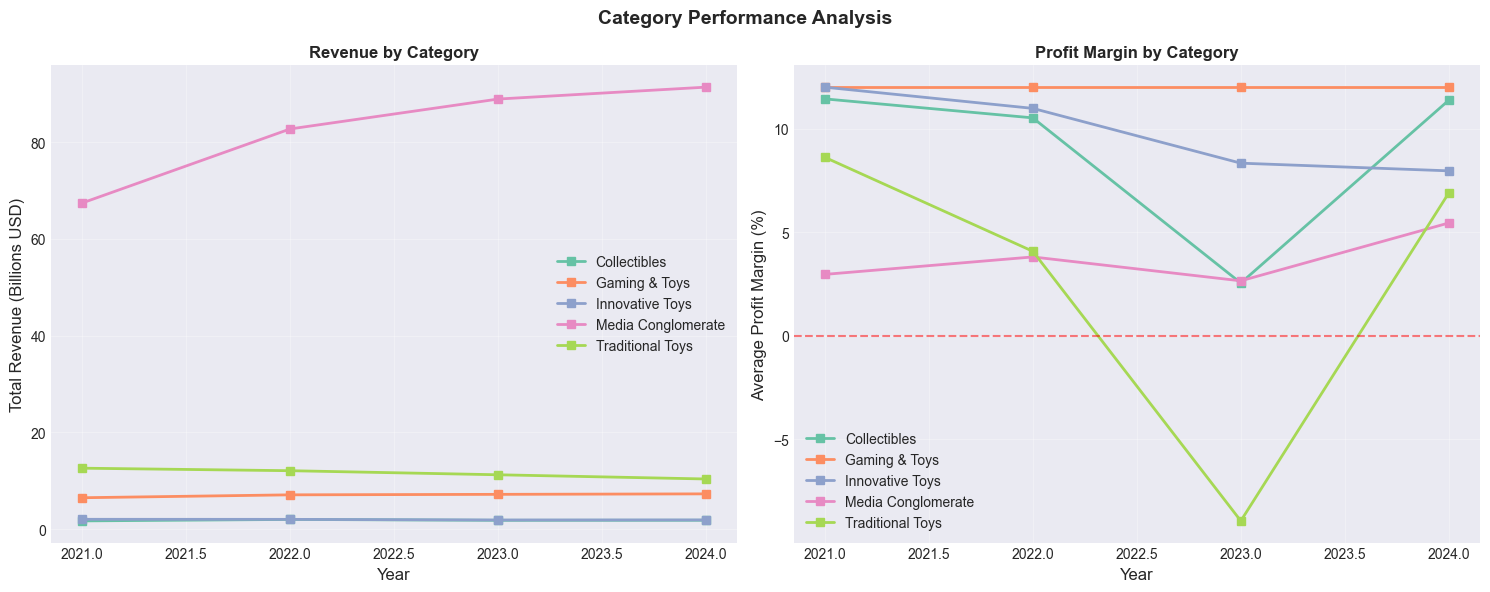

 Saved: category_analysis.png


In [319]:
category_performance = df.groupby(['category', 'year']).agg({
    'revenue_millions': 'sum',
    'profit_margin': 'mean'
}).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
for category in category_performance['category'].unique():
    cat_df = category_performance[category_performance['category'] == category]
    ax1.plot(cat_df['year'], cat_df['revenue_millions']/1000,
             marker='s', linewidth=2, label=category)

ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Total Revenue (Billions USD)', fontsize=12)
ax1.set_title('Revenue by Category', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
for category in category_performance['category'].unique():
    cat_df = category_performance[category_performance['category'] == category]
    ax2.plot(cat_df['year'], cat_df['profit_margin'],
             marker='s', linewidth=2, label=category)

ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Average Profit Margin (%)', fontsize=12)
ax2.set_title('Profit Margin by Category', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='red', linestyle='--', alpha=0.5)

plt.suptitle('Category Performance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('category_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Saved: category_analysis.png")


In [321]:
net_income_estimates = {
    'Disney': 4972, 'Hasbro': 386, 'Mattel': 556, 'Funko': 38,
    'JAKKS Pacific': 9, 'Bandai Namco': 876, 'Spin Master': 152, 'Pop Mart': 148
}

for company in df['company'].unique():
    mask = df['company'] == company
    df.loc[mask, 'net_income'] = net_income_estimates.get(company, 0)

df['profit_margin'] = (df['net_income'] / df['revenue_millions']) * 100
df['revenue_billions'] = df['revenue_millions'] / 1000
latest_year = df['year'].max()
latest_df = df[df['year'] == latest_year].copy()
print("Latest year data:")
print(latest_df[['company', 'revenue_billions', 'profit_margin']])


Latest year data:
          company  revenue_billions  profit_margin
3          Disney            91.361       5.442147
7          Hasbro             4.136       9.332689
11         Mattel             5.445      10.211203
15          Funko             1.080       3.518519
19  JAKKS Pacific             0.795       1.132075
23   Bandai Namco             7.300      12.000000
27    Spin Master             1.910       7.958115
31       Pop Mart             0.770      19.220779


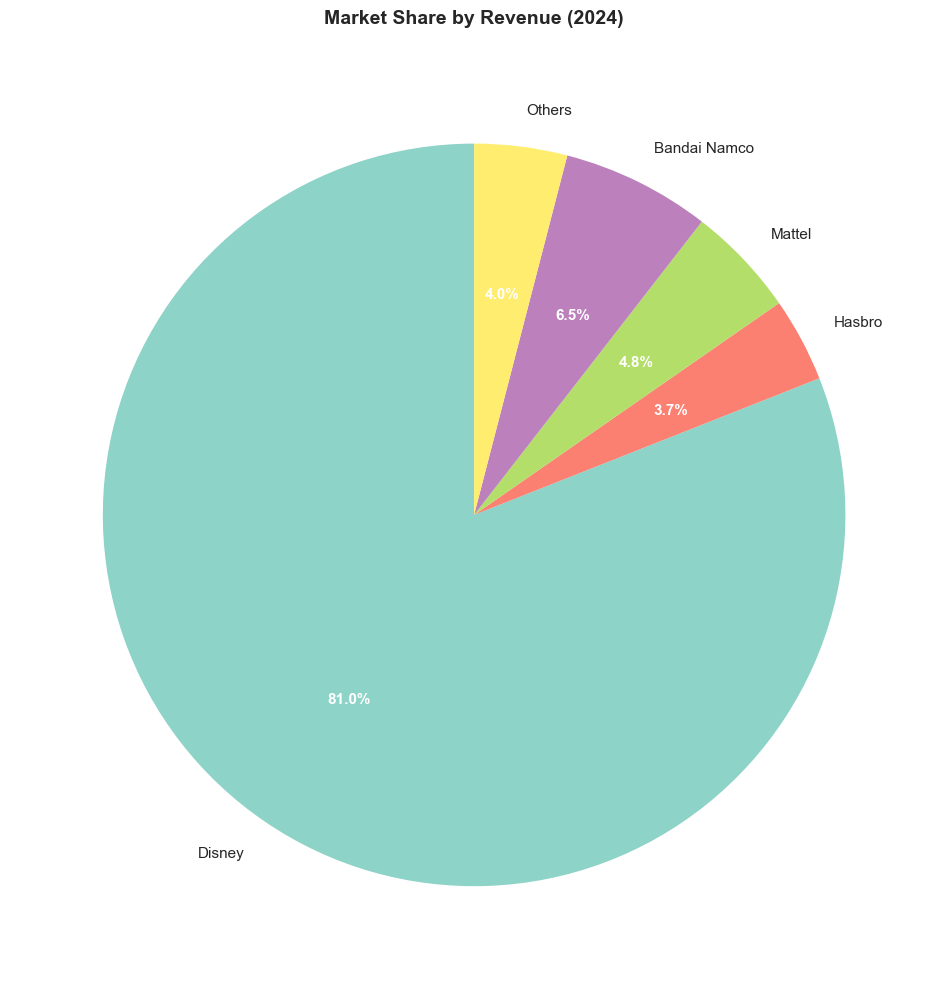

✅ Saved: market_share.png


In [322]:
fig, ax = plt.subplots(figsize=(10, 10))
revenue_data = latest_df[latest_df['revenue_millions'] > 0].copy()
threshold = 2000  # 2 billion threshold
others_sum = revenue_data[revenue_data['revenue_millions'] < threshold]['revenue_millions'].sum()
main_companies = revenue_data[revenue_data['revenue_millions'] >= threshold]

if others_sum > 0:
    plot_data = pd.concat([main_companies, 
                          pd.DataFrame({'company': ['Others'], 'revenue_millions': [others_sum]})])
else:
    plot_data = main_companies
colors_pie = plt.cm.Set3(np.linspace(0, 1, len(plot_data)))
wedges, texts, autotexts = ax.pie(plot_data['revenue_millions'],
                                    labels=plot_data['company'],
                                    autopct=lambda pct: f'{pct:.1f}%' if pct > 3 else '',
                                    colors=colors_pie,
                                    startangle=90,
                                    textprops={'fontsize': 11})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax.set_title(f'Market Share by Revenue ({latest_year})', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('market_share.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: market_share.png")

In [323]:
summary = df.groupby('company').agg({
    'revenue_billions': ['mean', 'last'],
    'profit_margin': ['mean', 'last'],
    'roa': 'mean'
}).round(2)

summary.columns = ['Avg Revenue (B)', 'Latest Revenue (B)', 'Avg Margin %', 'Latest Margin %', 'Avg ROA %']
summary = summary.sort_values('Latest Revenue (B)', ascending=False)

print("\n" + "="*60)
print("INDUSTRY SUMMARY STATISTICS")
print("="*60)
print(summary.to_string())


INDUSTRY SUMMARY STATISTICS
               Avg Revenue (B)  Latest Revenue (B)  Avg Margin %  Latest Margin %  Avg ROA %
company                                                                                     
Disney                   82.60               91.36          6.11             5.44       1.55
Bandai Namco              7.02                7.30         12.50            12.00      15.32
Mattel                    5.44                5.44         10.21            10.21       8.34
Hasbro                    5.35                4.14          7.41             9.33      -1.18
Spin Master               1.97                1.91          7.72             7.96      10.81
Funko                     1.13                1.08          3.40             3.52      -1.92
JAKKS Pacific             0.78                0.80          1.16             1.13       1.79
Pop Mart                  0.73                0.77         20.37            19.22      10.49


In [324]:
summary.to_csv('industry_summary.csv')
df.to_csv('toy_industry_data.csv', index=False)
print("\n Saved: industry_summary.csv, toy_industry_data.csv")


 Saved: industry_summary.csv, toy_industry_data.csv


In [325]:
print("\n" + "="*60)
print("KEY BUSINESS INSIGHTS")
print("="*60)


KEY BUSINESS INSIGHTS


In [ ]:
print("\n TOP PERFORMERS:")
top_revenue = summary['Latest Revenue (B)'].idxmax()
top_margin = summary['Latest Margin %'].idxmax()
top_roa = summary['Avg ROA %'].idxmax()
print(f"   Revenue Leader: {top_revenue} (${summary.loc[top_revenue, 'Latest Revenue (B)']:.1f}B)")
print(f"   Profitability Leader: {top_margin} ({summary.loc[top_margin, 'Latest Margin %']:.1f}% margin)")
print(f"   Efficiency Leader: {top_roa} ({summary.loc[top_roa, 'Avg ROA %']:.1f}% ROA)")

print("\n GROWTH STORIES:")
df['growth'] = df.groupby('company')['revenue_millions'].pct_change() * 100
avg_growth = df.groupby('company')['growth'].mean().dropna().sort_values(ascending=False)
print(f"   Fastest Growing: {avg_growth.index[0]} ({avg_growth.iloc[0]:.1f}% avg annual growth)")

print("\nAREAS OF CONCERN:")
negative_margins = summary[summary['Latest Margin %'] < 0]
if len(negative_margins) > 0:
    print(f"   Companies with negative margins: {', '.join(negative_margins.index)}")

print("\n" \
" Analysis complete! All files saved.")


 TOP PERFORMERS:
   Revenue Leader: Disney ($91.4B)
   Profitability Leader: Pop Mart (19.2% margin)
   Efficiency Leader: Bandai Namco (15.3% ROA)

 GROWTH STORIES:
   Fastest Growing: Disney (11.0% avg annual growth)

AREAS OF CONCERN:

 Analysis complete! All files saved.
